# Mini-Projet : Ajustement - Compte-rendu

## Introduction

Dans l'étude des effets du réchauffement climatique, la distinction entre climat (mesures de températures à l'échelle globale et sur de longues durées) et météorologie (mesures de températures à l'échelle locale et sur de courtes durées) est essentielle à la bonne compréhension des enjeux. Cependant, pouvons-nous détecter les effets du réchauffement climatique à l'échelle locale, mais à partir d'échantillons récoltés sur une longue période ?
Afin de mener à bien notre exercice de modélisation, nous utiliserons les relevés de températures enregistrés quotidiennement depuis juin 1920 à la station météorologique de Montélimar, accessibles sur le site de l'European Climate Assessment & Dataset.
Le dataset prétraité `montelimar_temperature.dat` contient ainsi 2 colonnes, regroupant respectivement les dates en MJD (Modified Julian Day) et les températures (en °C).

## I. Etude préliminaire

Avant toute chose, représentons les données brutes récoltées par la station par le biais de la bibliothèque `Pandas`, nous permettant de lire et traiter les relevés sous forme d'un DataFrame. Regroupons les données du fichier dans le DataFrame `data` :

In [1]:
import pandas as pd

data = pd.read_csv('montelimar_temperature.dat', delim_whitespace=True, names=['Dates', 'Temperatures'])

Le système de dates en MJD est fréquemment utilisée par les astronomes pour mesurer le temps écoulé entre deux événements. Cependant, il s'agit d'un système journalier continu dont l'origine est fixée au 17 novembre 1858 : convertissons-le donc en dates standard (Année-Mois-Jour), puis en jours :

In [2]:
# Conversion MJD -> Date standard
data['Dates'] = pd.to_datetime(data['Dates'], origin="1858-11-17", unit='D')

# Conversion MJD -> jours
t0 = data['Dates'].min()  # Origine
data['Jours'] = (data['Dates'] - t0).dt.days  # Jours depuis t0

Nous sommes désormais en capacité de représenter graphiquement l'évolution de la température.

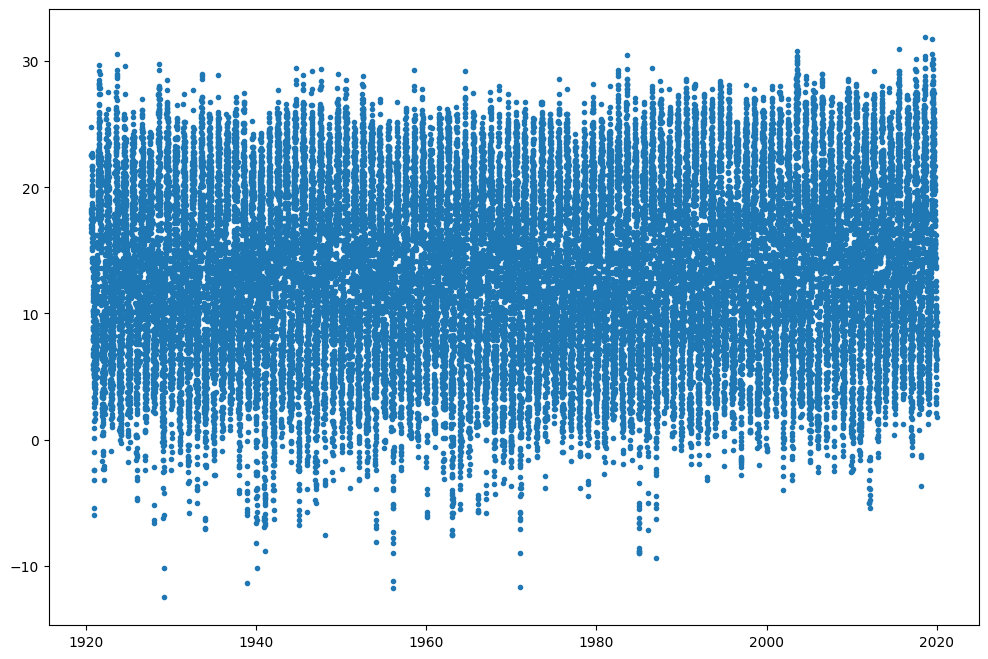

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(data['Dates'], data['Temperatures'], marker = '.')

Nous constatons que les données ne sont pas très lisibles : en effet, les températures sont enregistrées à une fréquence journalière, et sont ainsi sujettes aux variations saisonnières de température. Pour plus de clareté, il est donc pertinent de ne représenter que les moyennes annuelles de température.

In [4]:
import numpy as np

data['Année'] = data['Dates'].dt.year
moyenne_annuelle = data.groupby('Année')['Temperatures'].mean()

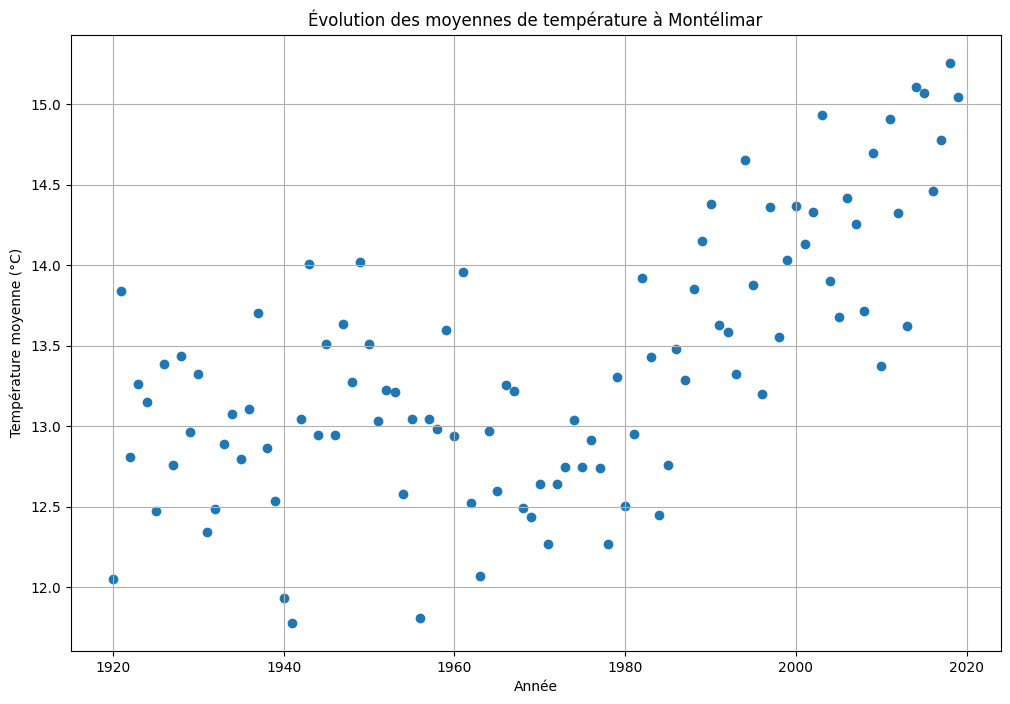

In [5]:
plt.figure(figsize=(12, 8))
plt.scatter(moyenne_annuelle.index, moyenne_annuelle, marker='o')
plt.xlabel("Année")
plt.ylabel("Température moyenne (°C)")
plt.title("Évolution des moyennes de température à Montélimar")
plt.grid()
plt.show()

Nous constatons, entre les années 1920 et 1980, des valeurs moyennes de température très dispersées et dont l'analyse ne permet d'en tirer aucune tendance générale. Toutefois, à partir des années 1980, nous discernons une tendance haussière linéaire des températures moyennes à Montélimar, pouvant témoigner d'un réchauffement accru sur les quatre dernières décennies.

## II. Modélisation

Les variations saisonnières de températures peuvent être modélisées par une sinusoïde de période annuelle de forme :

$$ T(t) = A \sin{(\omega t + \phi)} + B $$

où l'amplitude $A$, la phase à l'origine $\phi$ et la température moyenne $B$ doivent être ajustés aux données, tandis que la fréquence annuelle $\omega = \frac{2\pi}{1\text{ an}}$ est fixe.
Commençons par définir ce dernier modèle comme une fonction acceptant en entrée le temps, l'amplitude, la phase à l'origine et la température moyenne :

In [6]:
def model_sin(t, A, phi, B):
    omega = 2 * np.pi / 365.25
    return A * np.sin(omega * t + phi) + B

Importons ensuite les données de la station dans deux variables distinctes `t` (temps en jours) et `T` (température en °C) :

In [7]:
t = data['Jours'].values
T = data['Temperatures'].values

Utilisons la fonction `curve_fit` du module `scipy.optimize`, appliquée au modèle défini ci-dessus, pour ajuster les échantillons de température selon une sinusoïde. A l'aide de la matrice de covariance fournie par la fonction, calculons également les incertitudes liées aux différents paramètres.

In [8]:
import scipy.optimize as opt

parametres, pcov = opt.curve_fit(model_sin, t, T)
perr = np.sqrt(np.diag(pcov))
A_fit, phi_fit, B_fit = parametres

print(f"Paramètres ajustés :\n A = {A_fit:.3f} ± {perr[0]:.3f} °C \n phi = {phi_fit:.3f} ± {perr[1]:.3f} \n B = {B_fit:.3f} ± {perr[2]:.3f} °C")

Paramètres ajustés :
 A = 9.011 ± 0.024 °C 
 phi = 8.320 ± 0.003 
 B = 13.368 ± 0.017 °C


Représentons graphiquement le résultat de l'ajustement, superposé aux données numériques.

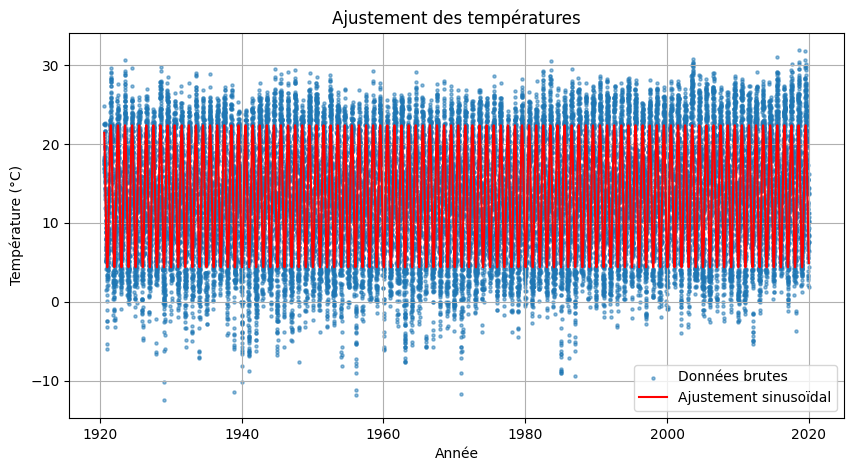

In [9]:
t_fit = np.linspace(t.min(), t.max(), 10000)
T_fit = model_sin(t_fit, A_fit, phi_fit, B_fit)

# Conversion Jours -> Dates
t_fit_dates = data['Dates'].min() + pd.to_timedelta(t_fit, unit='D')
t_dates = data['Dates'].min() + pd.to_timedelta(t, unit='D')

plt.figure(figsize=(10, 5))
plt.scatter(t_dates, T, s=5, alpha=0.5, label="Données brutes")
plt.plot(t_fit_dates, T_fit, color='red', label="Ajustement sinusoïdal")
plt.xlabel("Année")
plt.ylabel("Température (°C)")
plt.title("Ajustement des températures")
plt.legend()
plt.grid()
plt.show()

Nous constatons que la fonction résultant de l'ajustement est très efficace pour témoigner des variations saisonnières de températures, mais est incapable de représenter l'augmentation de ces dernières due au réchauffement climatique. Pour cela, remplaçons la fonction modélisatrice imposée ci-dessus par une autre composant un terme linéaire :

$$ T(t) = A \sin{(\omega t + \phi)} + B + C t $$

où $ C $ correspond à l'accroissement linéaire lent de la température.
Définissions donc ce nouveau modèle sous la forme d'une fonction :

In [10]:
def model(t, A, phi, B, C):
    omega = 2 * np.pi / 365.25
    return A * np.sin(omega * t + phi) + B + C * t

Comme ci-dessus, nous affichons les paramètres ajustés, ainsi que les incertitudes associées.

In [11]:
parametres, pcov = opt.curve_fit(model, t, T)

A_fit, phi_fit, B_fit, C_fit = parametres
perr = np.sqrt(np.diag(pcov))

print(f"Incertitudes sur C : {perr[3]:.4e}")
print(f"Paramètres ajustés :\n A = {A_fit:.3f} ± {perr[0]:.4f} \n phi = {phi_fit:.3f} ± {perr[1]:.4f} \n B = {B_fit:.3f} ± {perr[2]:.3f} \n C = {C_fit:.4e} ± {perr[3]:.7f}")

Incertitudes sur C : 1.5926e-06
Paramètres ajustés :
 A = 9.009 ± 0.0236 
 phi = 8.320 ± 0.0026 
 B = 12.530 ± 0.033 
 C = 4.6170e-05 ± 0.0000016


Finalement, nous générons la fonction ajustée sur un échantillon de 1000 valeurs temporelles disséminées entre 1920 et 2020, et la représentons aux côtés des données récoltées sur cette même période.

In [12]:
t_fit = np.linspace(t.min(), t.max(), 1000)
T_fit = model(t_fit, *parametres)

# Jours -> Dates
t_fit_dates = data['Dates'].min() + pd.to_timedelta(t_fit, unit='D')
t_dates = data['Dates'].min() + pd.to_timedelta(t, unit='D')

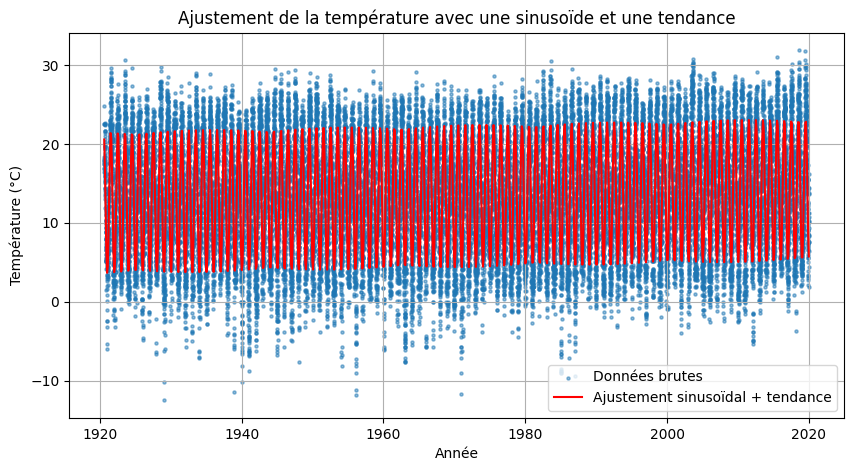

In [13]:
plt.figure(figsize=(10, 5))
plt.scatter(t_dates, T, s=5, alpha=0.5, label="Données brutes")
plt.plot(t_fit_dates, T_fit, color='red', label="Ajustement sinusoïdal + tendance")
plt.xlabel("Année")
plt.ylabel("Température (°C)")
plt.title("Ajustement de la température avec une sinusoïde et une tendance")
plt.legend()
plt.grid()
plt.show()

Voyons l'allure du graphe sur une fenêtre plus réduite :

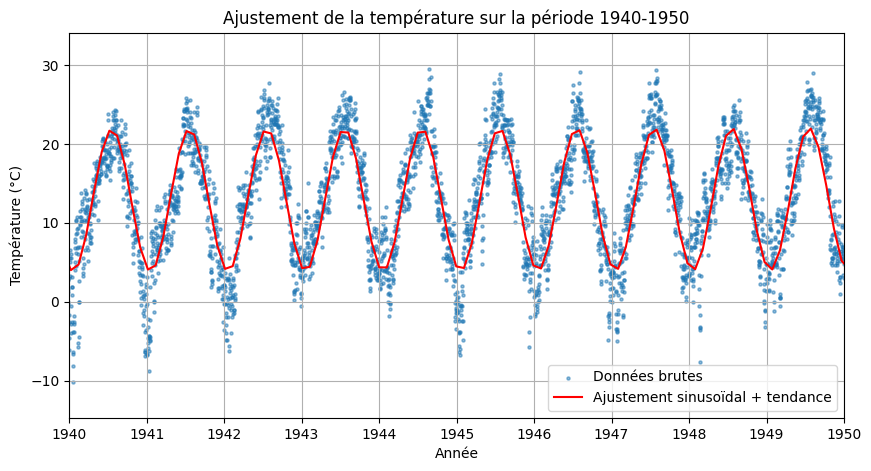

In [14]:
plt.figure(figsize=(10, 5))
plt.scatter(t_dates, T, s=5, alpha=0.5, label="Données brutes")
plt.plot(t_fit_dates, T_fit, color='red', label="Ajustement sinusoïdal + tendance")
plt.xlabel("Année")
plt.ylabel("Température (°C)")
plt.xlim(np.datetime64('1940', 'Y'), np.datetime64('1950', 'Y'))
plt.title("Ajustement de la température sur la période 1940-1950")
plt.legend()
plt.grid()
plt.show()

Nous constatons cette fois-ci que le modèle suit à la fois les variations saisonnières de températures, mais aussi l'accroissement linéaire de ces dernières, induit par le réchauffement climatique. Ce réchauffement s'opère, d'après les paramètres résultants du fitting, à un rythme de $4.615 \times 10^{-5} °C/j$, soit une hausse de $4.615 \times 10^{-5} \times 36294 j = 1.676°C$ depuis 1920. Représentons ainsi la moyenne décennales des températures, en approximant les variations saisonnières à une incertitude de 5°C sur la mesure.

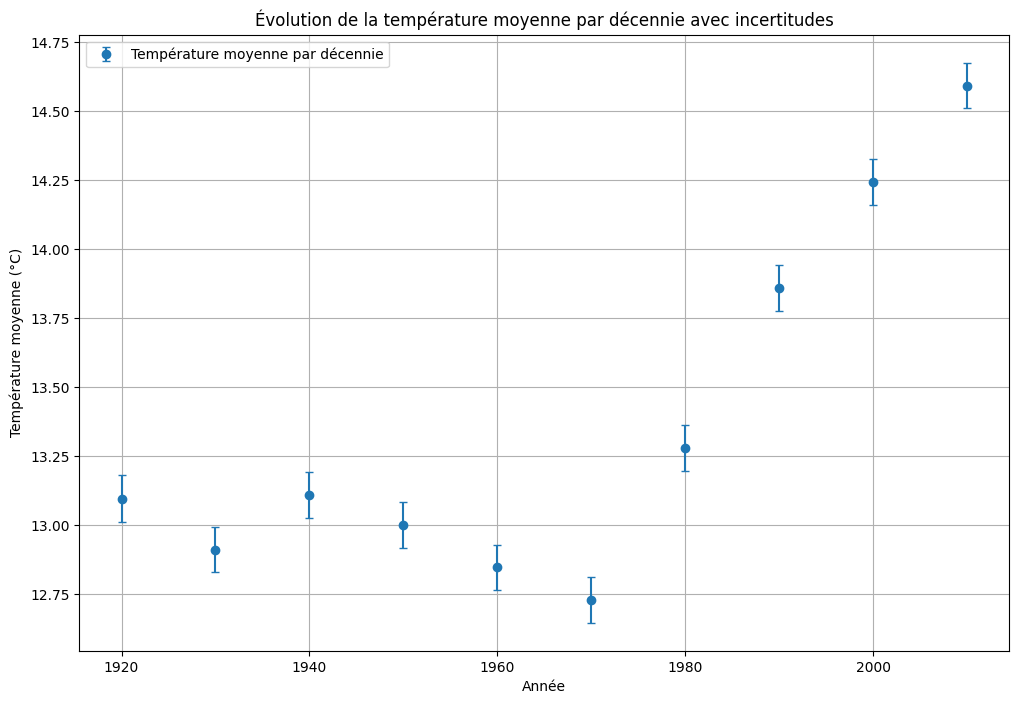

Les incertitudes sur les moyennes sont en moyenne de 0.0830 °C.


In [15]:
decennies = []
moyennes_B = []
incertitudes_B = []

# Ajustement du modèle par décennie
for annee_debut in range(data['Année'].min(), data['Année'].max(), 10):
    decennie = data[(data['Année'] >= annee_debut) & (data['Année'] < annee_debut + 10)]
    
    # Jours relatifs à la première date de la décennie
    t_valeurs = (decennie['Dates'] - decennie['Dates'].min()).dt.days.values
    T_valeurs = decennie['Temperatures'].values

    # Incertitudes
    sigma = np.full_like(T_valeurs, 5)

    # Ajustement avec curve_fit
    params, covariance = opt.curve_fit(model_sin, t_valeurs, T_valeurs, sigma=sigma, absolute_sigma=True)
    decennies.append(annee_debut)
    moyennes_B.append(params[2])
    
    # Incertitude sur B
    incertitude_B = np.sqrt(covariance[2, 2])
    incertitudes_B.append(incertitude_B)

plt.figure(figsize=(12, 8))
plt.errorbar(decennies, moyennes_B, yerr=incertitudes_B, fmt='o', capsize=3, label="Température moyenne par décennie")
plt.xlabel("Année")
plt.ylabel("Température moyenne (°C)")
plt.title("Évolution de la température moyenne par décennie avec incertitudes")
plt.legend()
plt.grid()
plt.show()

print(f"Les incertitudes sur les moyennes sont en moyenne de {(np.sqrt(sum(x**2 for x in incertitudes_B) / len(incertitudes_B))):.4f} °C.")

En utilisant le modèle sinusoïdal sur des périodes de 10 ans, pour lesquelles le réchauffement total est trop faible pour poser un problème d'ajustement, nous observons en effet une forte augmentation des moyennes de températures décennales dès les années 1980. Les incertitudes sur les moyennes étant relativement faibles (de l'ordre du dixième de degré Celsius) comparées au réchauffement total des températures depuis 1920 (1,68°C), nous pouvons en conclure que le réchauffement observé à l'échelle locale sur les 100 dernières années n'est pas dû à de quelconques fluctuations statistiques ou variations saisonnières de températures, mais à un phénomène continu d'ampleur non-négligeable.

## Conclusion

À travers ce mini-projet, nous avons exploré la possibilité de détecter les effets du réchauffement climatique, à l'échelle locale, en analysant les relevés de température de la station météorologique de Montélimar. Nous avons pu identifier des tendances sous-jacentes dans les données et ainsi mettre en évidence l'évolution des températures sur près d'un siècle : les analyses effectuées ont permis de démontrer une évolution générale à la hausse des températures moyennes, en accord avec les observations climatiques globales, et de la quantifier.